# PatrolIQ - Temporal Crime Pattern Clustering
## Notebook 5: Unsupervised Learning - Time-Based Analysis

**Objective:**
- Cluster crimes based on temporal features
- Identify peak crime time periods
- Discover seasonal patterns
- Find 3-5 distinct time-based crime behaviors
- Track experiments with MLflow

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load and Prepare Data

In [2]:
# Load processed dataset
PROCESSED_DATA_PATH = '../data/processed/chicago_crimes_processed.csv'
ARTIFACTS_PATH = '../data/artifacts/'

print("Loading processed dataset...")
df = pd.read_csv(PROCESSED_DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Loading processed dataset...
Dataset shape: (498569, 43)
Date range: 2024-01-31 09:48:00 to 2026-02-14 00:00:00


In [3]:
# Display available temporal features
temporal_cols = ['Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Is_Late_Night', 
                 'Is_Rush_Hour', 'Season_Encoded', 'Crime_Severity']

print("\nTemporal features available:")
for col in temporal_cols:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (missing)")


Temporal features available:
  ✓ Hour
  ✓ Day_of_Week
  ✓ Month
  ✓ Is_Weekend
  ✓ Is_Late_Night
  ✓ Is_Rush_Hour
  ✓ Season_Encoded
  ✓ Crime_Severity


## Step 2: Prepare Temporal Feature Matrix

In [4]:
# Select temporal features for clustering
temporal_features = ['Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 
                     'Is_Late_Night', 'Is_Rush_Hour', 'Season_Encoded']

# Create feature matrix
X_temporal = df[temporal_features].copy()

print(f"Temporal feature matrix shape: {X_temporal.shape}")
print(f"\nFeatures: {temporal_features}")
print(f"\nFeature statistics:")
print(X_temporal.describe().T)

Temporal feature matrix shape: (498569, 7)

Features: ['Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Is_Late_Night', 'Is_Rush_Hour', 'Season_Encoded']

Feature statistics:
                   count       mean       std  min  25%   50%   75%   max
Hour            498569.0  12.498236  6.828375  0.0  8.0  13.0  18.0  23.0
Day_of_Week     498569.0   3.014836  1.998503  0.0  1.0   3.0   5.0   6.0
Month           498569.0   6.507400  3.352288  1.0  4.0   7.0   9.0  12.0
Is_Weekend      498569.0   0.287411  0.452555  0.0  0.0   0.0   1.0   1.0
Is_Late_Night   498569.0   0.238872  0.426395  0.0  0.0   0.0   0.0   1.0
Is_Rush_Hour    498569.0   0.260449  0.438880  0.0  0.0   0.0   1.0   1.0
Season_Encoded  498569.0   1.485848  1.101703  0.0  1.0   2.0   2.0   3.0


In [5]:
# Normalize temporal features for better clustering
print("\nNormalizing temporal features...")

scaler_temporal = StandardScaler()
X_temporal_scaled = scaler_temporal.fit_transform(X_temporal)

print("✓ Features normalized using StandardScaler")
print(f"Scaled feature matrix shape: {X_temporal_scaled.shape}")


Normalizing temporal features...
✓ Features normalized using StandardScaler
Scaled feature matrix shape: (498569, 7)


## Step 3: Setup MLflow Tracking

In [6]:
# Configure MLflow
mlflow.set_tracking_uri("file:../mlflow_tracking")
mlflow.set_experiment("PatrolIQ_Temporal_Clustering")

print("✓ MLflow tracking configured")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: PatrolIQ_Temporal_Clustering")

✓ MLflow tracking configured
Tracking URI: file:../mlflow_tracking
Experiment: PatrolIQ_Temporal_Clustering


## Step 4: Elbow Method for Optimal K

In [7]:
# Elbow method to find optimal number of temporal clusters
print("Running Elbow Method to determine optimal K for temporal patterns...\n")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

SILHOUETTE_SAMPLE_SIZE = 10000

for k in K_range:
    print(f"Testing K={k}...", end=" ")
    
    kmeans_temporal = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temporal.fit_predict(X_temporal_scaled)
    
    inertias.append(kmeans_temporal.inertia_)
    
    if len(X_temporal_scaled) > SILHOUETTE_SAMPLE_SIZE:
        sample_indices = []
        for cluster_id in np.unique(labels):
            cluster_indices = np.where(labels == cluster_id)[0]
            n_samples_cluster = min(
                len(cluster_indices),
                max(1, int(SILHOUETTE_SAMPLE_SIZE * len(cluster_indices) / len(X_temporal_scaled)))
            )
            sampled = np.random.choice(cluster_indices, size=n_samples_cluster, replace=False)
            sample_indices.extend(sampled)
        
        sample_indices = np.array(sample_indices)
        X_sample = X_temporal_scaled[sample_indices]
        labels_sample = labels[sample_indices]
        
        sil_score = silhouette_score(X_sample, labels_sample)
    else:
        sil_score = silhouette_score(X_temporal_scaled, labels)
    
    silhouette_scores.append(sil_score)
    
    db_score = davies_bouldin_score(X_temporal_scaled, labels)
    davies_bouldin_scores.append(db_score)
    
    print(f"Silhouette: {sil_score:.3f}, Davies-Bouldin: {db_score:.3f}")

print("\n✓ Elbow method analysis complete!")


Running Elbow Method to determine optimal K for temporal patterns...

Testing K=2... Silhouette: 0.265, Davies-Bouldin: 1.579
Testing K=3... Silhouette: 0.236, Davies-Bouldin: 1.544
Testing K=4... Silhouette: 0.278, Davies-Bouldin: 1.401
Testing K=5... Silhouette: 0.300, Davies-Bouldin: 1.315
Testing K=6... Silhouette: 0.289, Davies-Bouldin: 1.237
Testing K=7... Silhouette: 0.312, Davies-Bouldin: 1.170
Testing K=8... Silhouette: 0.331, Davies-Bouldin: 1.209
Testing K=9... Silhouette: 0.319, Davies-Bouldin: 1.217
Testing K=10... Silhouette: 0.316, Davies-Bouldin: 1.142

✓ Elbow method analysis complete!


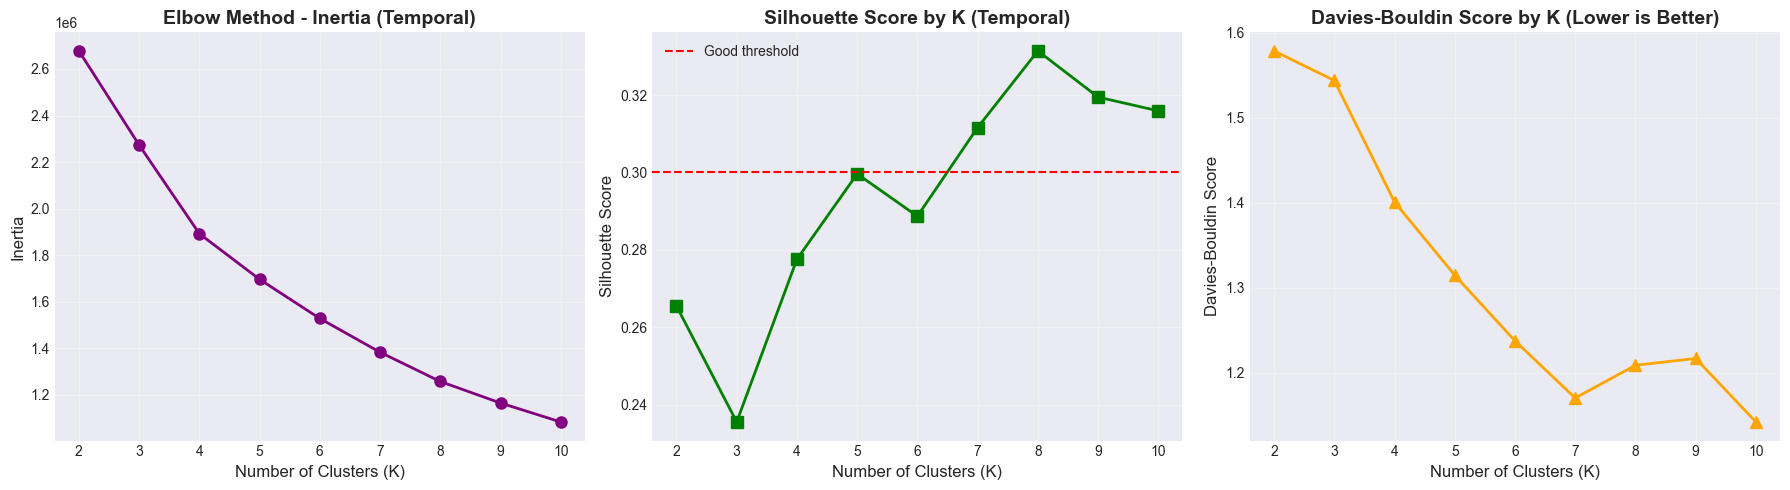

In [8]:
# Visualize elbow method results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inertia plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='purple')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method - Inertia (Temporal)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, 
             markersize=8, color='green')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by K (Temporal)', fontsize=14, fontweight='bold')
axes[1].axhline(y=0.3, color='r', linestyle='--', label='Good threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin score plot
axes[2].plot(K_range, davies_bouldin_scores, marker='^', linewidth=2, 
             markersize=8, color='orange')
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[2].set_title('Davies-Bouldin Score by K (Lower is Better)', 
                  fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Select optimal K
optimal_k_temporal = K_range[np.argmax(silhouette_scores)]
print(f"\n=== Optimal K Selection ===")
print(f"Based on Silhouette Score: K = {optimal_k_temporal}")
print(f"Maximum Silhouette Score: {max(silhouette_scores):.3f}")
print(f"\nExpected: 3-5 distinct time-based crime patterns")


=== Optimal K Selection ===
Based on Silhouette Score: K = 8
Maximum Silhouette Score: 0.331

Expected: 3-5 distinct time-based crime patterns


## Step 5: Apply K-Means Temporal Clustering

In [10]:
# Apply K-Means with optimal K
print(f"\nApplying K-Means temporal clustering with K={optimal_k_temporal}...")

with mlflow.start_run(run_name="KMeans_Temporal"):
    
    # Fit K-Means on full dataset
    kmeans_temporal = KMeans(n_clusters=optimal_k_temporal, random_state=42, n_init=10)
    df['Temporal_Cluster'] = kmeans_temporal.fit_predict(X_temporal_scaled)
    
    # Memory-safe silhouette score computation using stratified sampling
    # Reason: silhouette_score computes O(n²) pairwise distances
    # For large datasets (>10k rows), this causes long execution time and high memory usage
    # Solution: Use stratified sampling to maintain cluster distribution
    SILHOUETTE_SAMPLE_SIZE = 10000
    
    if len(X_temporal_scaled) > SILHOUETTE_SAMPLE_SIZE:
        # Stratified sampling: maintain cluster proportions
        sample_indices = []
        labels = df['Temporal_Cluster'].values
        
        for cluster_id in np.unique(labels):
            cluster_indices = np.where(labels == cluster_id)[0]
            n_samples_cluster = min(
                len(cluster_indices),
                max(1, int(SILHOUETTE_SAMPLE_SIZE * len(cluster_indices) / len(X_temporal_scaled)))
            )
            sampled = np.random.choice(cluster_indices, size=n_samples_cluster, replace=False)
            sample_indices.extend(sampled)
        
        sample_indices = np.array(sample_indices)
        X_sample = X_temporal_scaled[sample_indices]
        labels_sample = labels[sample_indices]
        
        temporal_silhouette = silhouette_score(X_sample, labels_sample)
    else:
        temporal_silhouette = silhouette_score(X_temporal_scaled, df['Temporal_Cluster'])
    
    # Davies-Bouldin score is memory-efficient (uses cluster centroids)
    temporal_db = davies_bouldin_score(X_temporal_scaled, df['Temporal_Cluster'])
    
    # Log parameters and metrics to MLflow
    mlflow.log_param("algorithm", "KMeans_Temporal")
    mlflow.log_param("n_clusters", optimal_k_temporal)
    mlflow.log_param("features", ",".join(temporal_features))
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("silhouette_score", temporal_silhouette)
    mlflow.log_metric("davies_bouldin_score", temporal_db)
    mlflow.log_metric("inertia", kmeans_temporal.inertia_)
    
    print(f"\n✓ Temporal clustering complete!")
    print(f"Silhouette Score: {temporal_silhouette:.3f}")
    print(f"Davies-Bouldin Score: {temporal_db:.3f}")
    print(f"Inertia: {kmeans_temporal.inertia_:.2f}")



Applying K-Means temporal clustering with K=8...

✓ Temporal clustering complete!
Silhouette Score: 0.330
Davies-Bouldin Score: 1.209
Inertia: 1257265.61


## Step 6: Analyze Temporal Clusters

In [11]:
# Comprehensive cluster analysis
print("\n=== TEMPORAL CLUSTER ANALYSIS ===")
print("\n1. Cluster Size Distribution:")
cluster_sizes = df['Temporal_Cluster'].value_counts().sort_index()
for cluster_id, size in cluster_sizes.items():
    print(f"   Cluster {cluster_id}: {size:,} crimes ({size/len(df)*100:.2f}%)")


=== TEMPORAL CLUSTER ANALYSIS ===

1. Cluster Size Distribution:
   Cluster 0: 33,661 crimes (6.75%)
   Cluster 1: 69,831 crimes (14.01%)
   Cluster 2: 28,381 crimes (5.69%)
   Cluster 3: 71,691 crimes (14.38%)
   Cluster 4: 81,252 crimes (16.30%)
   Cluster 5: 136,052 crimes (27.29%)
   Cluster 6: 28,184 crimes (5.65%)
   Cluster 7: 49,517 crimes (9.93%)


In [12]:
# Analyze temporal characteristics of each cluster
print("\n2. Temporal Characteristics by Cluster:\n")

for cluster_id in sorted(df['Temporal_Cluster'].unique()):
    cluster_data = df[df['Temporal_Cluster'] == cluster_id]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} - {len(cluster_data):,} crimes")
    print(f"{'='*70}")
    
    # Most common hour
    top_hour = cluster_data['Hour'].mode()[0]
    hour_count = (cluster_data['Hour'] == top_hour).sum()
    print(f"Peak Hour: {top_hour}:00 ({hour_count:,} crimes)")
    
    # Most common day
    top_day = cluster_data['Day_Name'].mode()[0]
    day_count = (cluster_data['Day_Name'] == top_day).sum()
    print(f"Peak Day: {top_day} ({day_count:,} crimes)")
    
    # Most common month
    top_month = cluster_data['Month_Name'].mode()[0]
    month_count = (cluster_data['Month_Name'] == top_month).sum()
    print(f"Peak Month: {top_month} ({month_count:,} crimes)")
    
    # Weekend percentage
    weekend_pct = cluster_data['Is_Weekend'].mean() * 100
    print(f"Weekend Crimes: {weekend_pct:.1f}%")
    
    # Late night percentage
    late_night_pct = cluster_data['Is_Late_Night'].mean() * 100
    print(f"Late Night Crimes (10PM-4AM): {late_night_pct:.1f}%")
    
    # Rush hour percentage
    rush_hour_pct = cluster_data['Is_Rush_Hour'].mean() * 100
    print(f"Rush Hour Crimes: {rush_hour_pct:.1f}%")
    
    # Average crime severity
    avg_severity = cluster_data['Crime_Severity'].mean()
    print(f"Average Crime Severity: {avg_severity:.2f}/5")
    
    # Arrest rate
    arrest_rate = cluster_data['Arrest'].mean() * 100
    print(f"Arrest Rate: {arrest_rate:.2f}%")
    
    # Top crime type
    top_crime = cluster_data['Primary Type'].value_counts().index[0]
    crime_count = cluster_data['Primary Type'].value_counts().values[0]
    print(f"Most Common Crime: {top_crime} ({crime_count:,})")


2. Temporal Characteristics by Cluster:


CLUSTER 0 - 33,661 crimes
Peak Hour: 17:00 (7,198 crimes)
Peak Day: Saturday (17,319 crimes)
Peak Month: June (3,265 crimes)
Weekend Crimes: 100.0%
Late Night Crimes (10PM-4AM): 0.0%
Rush Hour Crimes: 100.0%
Average Crime Severity: 2.74/5
Arrest Rate: 16.28%
Most Common Crime: THEFT (8,190)

CLUSTER 1 - 69,831 crimes
Peak Hour: 12:00 (5,211 crimes)
Peak Day: Friday (14,264 crimes)
Peak Month: October (25,374 crimes)
Weekend Crimes: 0.0%
Late Night Crimes (10PM-4AM): 0.0%
Rush Hour Crimes: 35.1%
Average Crime Severity: 2.71/5
Arrest Rate: 14.57%
Most Common Crime: THEFT (17,894)

CLUSTER 2 - 28,381 crimes
Peak Hour: 0:00 (10,783 crimes)
Peak Day: Sunday (15,037 crimes)
Peak Month: June (2,952 crimes)
Weekend Crimes: 100.0%
Late Night Crimes (10PM-4AM): 100.0%
Rush Hour Crimes: 0.0%
Average Crime Severity: 2.84/5
Arrest Rate: 13.28%
Most Common Crime: BATTERY (6,693)

CLUSTER 3 - 71,691 crimes
Peak Hour: 17:00 (14,617 crimes)
Peak Day: Friday (1

In [13]:
# Create summary statistics table
cluster_summary = df.groupby('Temporal_Cluster').agg({
    'Hour': 'mean',
    'Day_of_Week': 'mean',
    'Month': 'mean',
    'Is_Weekend': 'mean',
    'Is_Late_Night': 'mean',
    'Crime_Severity': 'mean',
    'Arrest': 'mean',
    'Primary Type': 'count'
}).round(2)

cluster_summary.columns = ['Avg_Hour', 'Avg_Day', 'Avg_Month', 'Weekend_%', 
                           'Late_Night_%', 'Avg_Severity', 'Arrest_Rate_%', 'Crime_Count']

cluster_summary['Weekend_%'] *= 100
cluster_summary['Late_Night_%'] *= 100
cluster_summary['Arrest_Rate_%'] *= 100

print("\n3. Summary Statistics by Cluster:")
print(cluster_summary)


3. Summary Statistics by Cluster:
                  Avg_Hour  Avg_Day  Avg_Month  Weekend_%  Late_Night_%  \
Temporal_Cluster                                                          
0                    14.39     5.49       6.53      100.0           0.0   
1                    13.76     2.01       9.95        0.0           0.0   
2                     1.19     5.53       6.62      100.0         100.0   
3                    14.07     2.00       5.31        0.0           0.0   
4                    14.91     5.48       6.51      100.0          16.0   
5                    13.58     2.02       5.32        0.0           0.0   
6                    22.47     2.12       6.59        0.0         100.0   
7                     1.03     1.98       6.54        0.0         100.0   

                  Avg_Severity  Arrest_Rate_%  Crime_Count  
Temporal_Cluster                                            
0                         2.74           16.0        33661  
1                         2.71 

## Step 7: Visualize Temporal Patterns

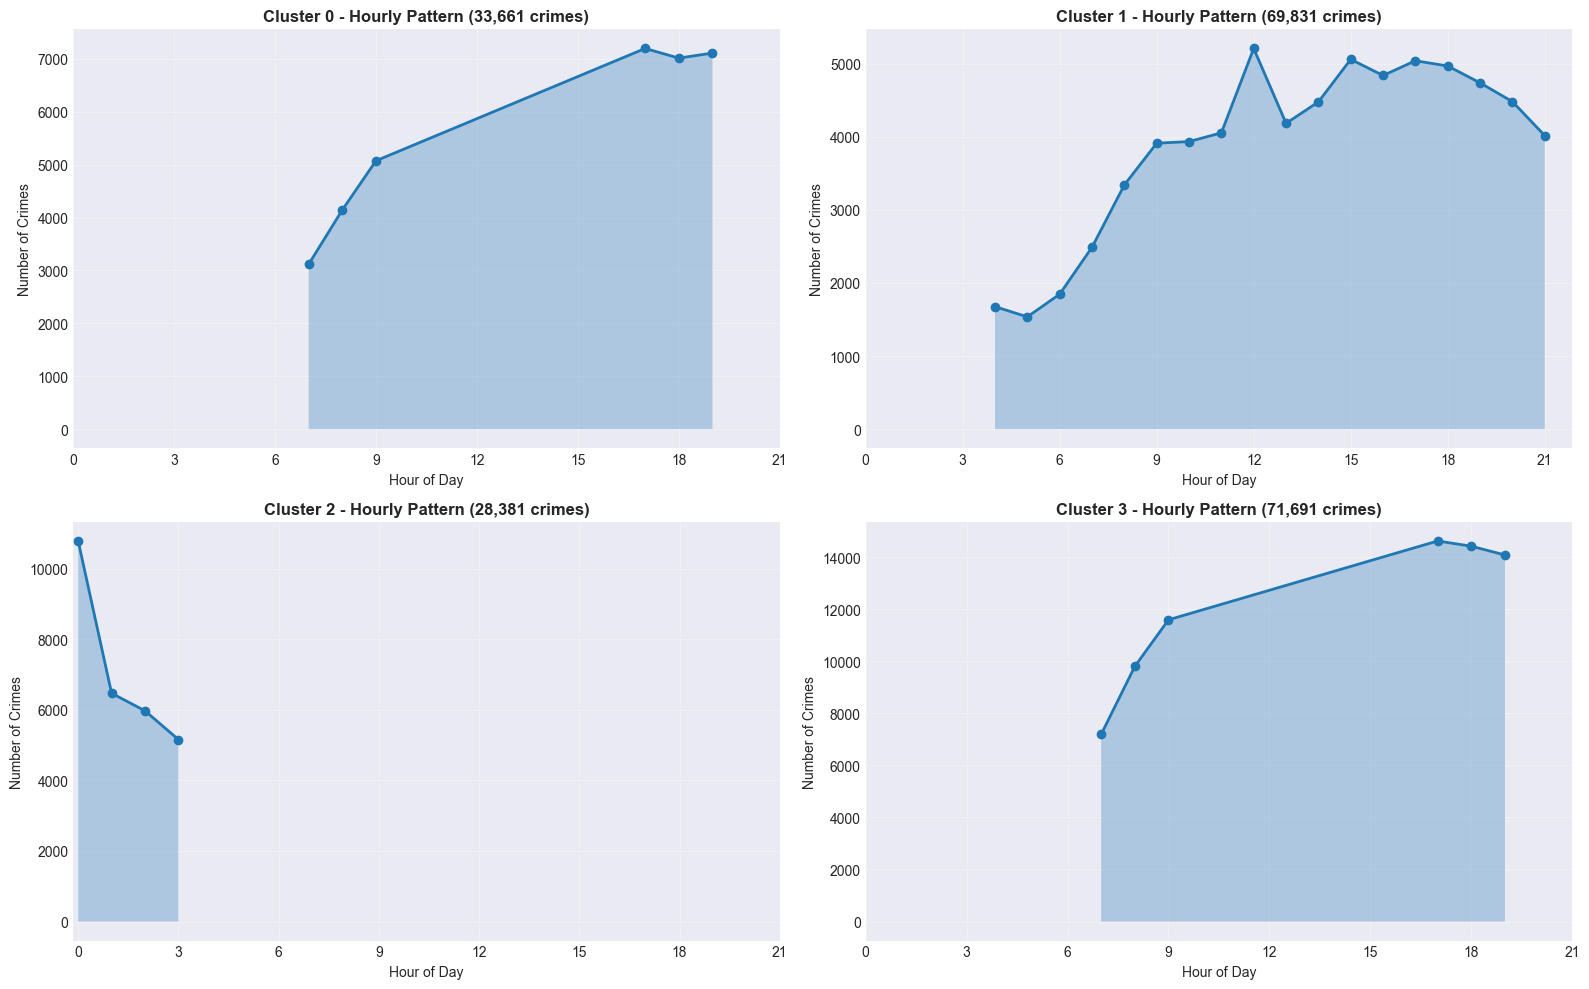

In [14]:
# Hourly distribution by cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, cluster_id in enumerate(sorted(df['Temporal_Cluster'].unique())):
    if idx < 4:
        cluster_data = df[df['Temporal_Cluster'] == cluster_id]
        hourly_dist = cluster_data['Hour'].value_counts().sort_index()
        
        axes[idx].plot(hourly_dist.index, hourly_dist.values, 
                      marker='o', linewidth=2, markersize=6)
        axes[idx].fill_between(hourly_dist.index, hourly_dist.values, alpha=0.3)
        axes[idx].set_title(f'Cluster {cluster_id} - Hourly Pattern ({len(cluster_data):,} crimes)', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Hour of Day', fontsize=10)
        axes[idx].set_ylabel('Number of Crimes', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

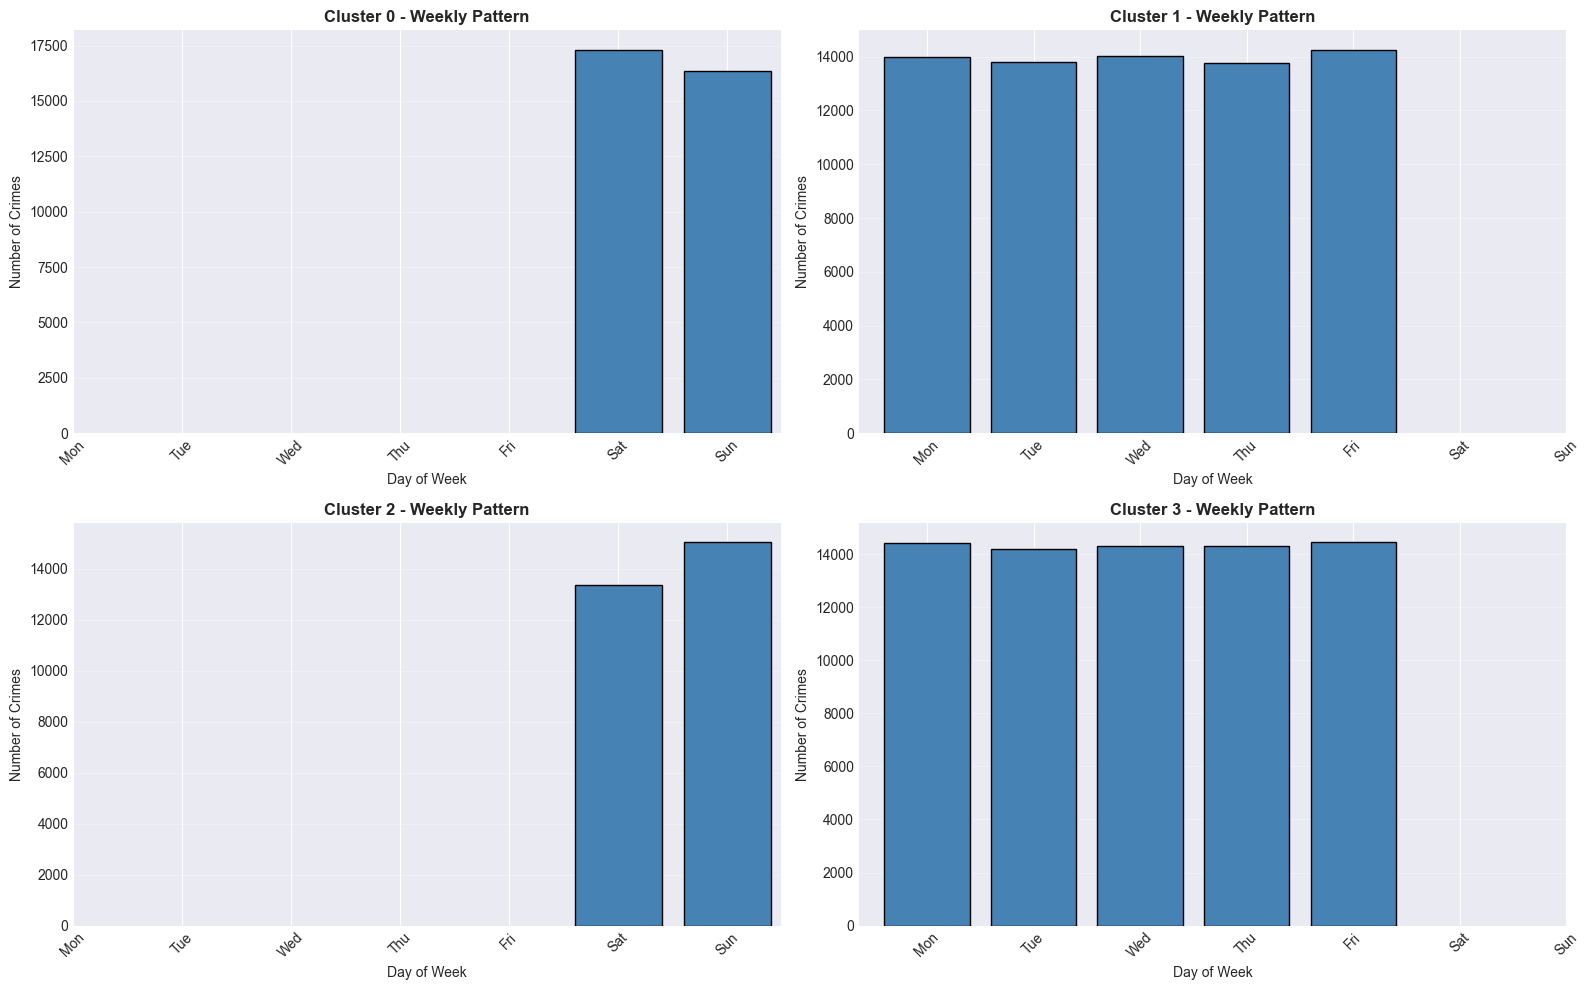

In [15]:
# Day of week distribution by cluster
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, cluster_id in enumerate(sorted(df['Temporal_Cluster'].unique())):
    if idx < 4:
        cluster_data = df[df['Temporal_Cluster'] == cluster_id]
        daily_dist = cluster_data['Day_Name'].value_counts().reindex(day_order)
        
        axes[idx].bar(range(7), daily_dist.values, color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Cluster {cluster_id} - Weekly Pattern', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Day of Week', fontsize=10)
        axes[idx].set_ylabel('Number of Crimes', fontsize=10)
        axes[idx].set_xticks(range(7))
        axes[idx].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
                                  rotation=45)
        axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

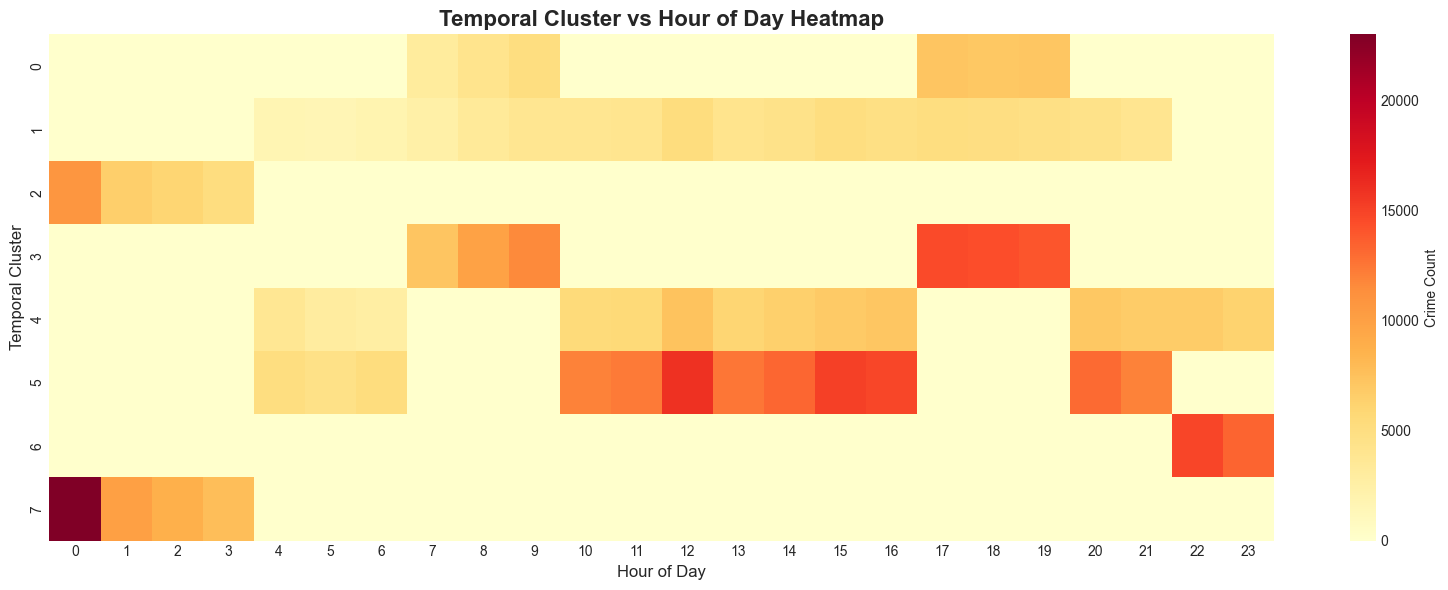

In [16]:
# Heatmap: Cluster vs Hour
cluster_hour_pivot = df.groupby(['Temporal_Cluster', 'Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 6))
sns.heatmap(cluster_hour_pivot, cmap='YlOrRd', annot=False, fmt='d', 
            cbar_kws={'label': 'Crime Count'})
plt.title('Temporal Cluster vs Hour of Day Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Temporal Cluster', fontsize=12)
plt.tight_layout()
plt.show()

## Step 8: Identify Peak Crime Times

In [17]:
# Identify high-risk time windows
print("\n" + "="*80)
print("HIGH-RISK TIME WINDOWS IDENTIFICATION")
print("="*80)

# Overall peak hours
hourly_crimes = df['Hour'].value_counts().sort_index()
threshold = hourly_crimes.quantile(0.75)
high_risk_hours = hourly_crimes[hourly_crimes >= threshold].index.tolist()

print(f"\n1. HIGH-RISK HOURS (Top 25%):")
print(f"   Hours: {', '.join([f'{h}:00' for h in sorted(high_risk_hours)])}")

# Peak days
daily_crimes = df['Day_Name'].value_counts()
peak_day = daily_crimes.idxmax()
print(f"\n2. PEAK DAY:")
print(f"   {peak_day} ({daily_crimes[peak_day]:,} crimes)")

# Peak months
monthly_crimes = df['Month_Name'].value_counts()
peak_month = monthly_crimes.idxmax()
print(f"\n3. PEAK MONTH:")
print(f"   {peak_month} ({monthly_crimes[peak_month]:,} crimes)")

# Weekend vs Weekday
weekend_crimes = df[df['Is_Weekend'] == 1].shape[0]
weekday_crimes = df[df['Is_Weekend'] == 0].shape[0]
print(f"\n4. WEEKEND vs WEEKDAY:")
print(f"   Weekday: {weekday_crimes:,} crimes ({weekday_crimes/len(df)*100:.1f}%)")
print(f"   Weekend: {weekend_crimes:,} crimes ({weekend_crimes/len(df)*100:.1f}%)")

# Late night crimes
late_night_crimes = df[df['Is_Late_Night'] == 1].shape[0]
print(f"\n5. LATE NIGHT CRIMES (10 PM - 4 AM):")
print(f"   Total: {late_night_crimes:,} crimes ({late_night_crimes/len(df)*100:.1f}%)")


HIGH-RISK TIME WINDOWS IDENTIFICATION

1. HIGH-RISK HOURS (Top 25%):
   Hours: 0:00, 12:00, 15:00, 16:00, 17:00, 18:00

2. PEAK DAY:
   Friday (73,594 crimes)

3. PEAK MONTH:
   July (46,652 crimes)

4. WEEKEND vs WEEKDAY:
   Weekday: 355,275 crimes (71.3%)
   Weekend: 143,294 crimes (28.7%)

5. LATE NIGHT CRIMES (10 PM - 4 AM):
   Total: 119,094 crimes (23.9%)


## Step 9: Cluster Labeling and Interpretation

In [18]:
# Assign meaningful labels to clusters based on characteristics
print("\n=== TEMPORAL CLUSTER INTERPRETATION ===")

cluster_labels = {}

for cluster_id in sorted(df['Temporal_Cluster'].unique()):
    cluster_data = df[df['Temporal_Cluster'] == cluster_id]
    
    avg_hour = cluster_data['Hour'].mean()
    weekend_pct = cluster_data['Is_Weekend'].mean()
    late_night_pct = cluster_data['Is_Late_Night'].mean()
    
    # Label based on characteristics
    if late_night_pct > 0.5:
        label = "Late Night Pattern"
    elif weekend_pct > 0.35:
        label = "Weekend Pattern"
    elif 7 <= avg_hour <= 9 or 17 <= avg_hour <= 19:
        label = "Rush Hour Pattern"
    elif avg_hour < 12:
        label = "Morning Pattern"
    elif 12 <= avg_hour < 18:
        label = "Afternoon Pattern"
    else:
        label = "Evening Pattern"
    
    cluster_labels[cluster_id] = label
    
    print(f"\nCluster {cluster_id}: {label}")
    print(f"  - Average Hour: {avg_hour:.1f}")
    print(f"  - Weekend Rate: {weekend_pct*100:.1f}%")
    print(f"  - Late Night Rate: {late_night_pct*100:.1f}%")
    print(f"  - Crime Count: {len(cluster_data):,}")

# Add labels to dataframe
df['Temporal_Pattern'] = df['Temporal_Cluster'].map(cluster_labels)


=== TEMPORAL CLUSTER INTERPRETATION ===

Cluster 0: Weekend Pattern
  - Average Hour: 14.4
  - Weekend Rate: 100.0%
  - Late Night Rate: 0.0%
  - Crime Count: 33,661

Cluster 1: Afternoon Pattern
  - Average Hour: 13.8
  - Weekend Rate: 0.0%
  - Late Night Rate: 0.0%
  - Crime Count: 69,831

Cluster 2: Late Night Pattern
  - Average Hour: 1.2
  - Weekend Rate: 100.0%
  - Late Night Rate: 100.0%
  - Crime Count: 28,381

Cluster 3: Afternoon Pattern
  - Average Hour: 14.1
  - Weekend Rate: 0.0%
  - Late Night Rate: 0.0%
  - Crime Count: 71,691

Cluster 4: Weekend Pattern
  - Average Hour: 14.9
  - Weekend Rate: 100.0%
  - Late Night Rate: 16.0%
  - Crime Count: 81,252

Cluster 5: Afternoon Pattern
  - Average Hour: 13.6
  - Weekend Rate: 0.0%
  - Late Night Rate: 0.0%
  - Crime Count: 136,052

Cluster 6: Late Night Pattern
  - Average Hour: 22.5
  - Weekend Rate: 0.0%
  - Late Night Rate: 100.0%
  - Crime Count: 28,184

Cluster 7: Late Night Pattern
  - Average Hour: 1.0
  - Weekend Rat

## Step 10: Save Temporal Clustering Results

In [19]:
# Save temporal clustering results
temporal_cluster_columns = [
    'Date', 'Hour', 'Day_of_Week', 'Day_Name', 'Month', 'Month_Name', 'Season',
    'Is_Weekend', 'Is_Late_Night', 'Is_Rush_Hour',
    'Primary Type', 'Crime_Severity', 'Arrest',
    'Temporal_Cluster', 'Temporal_Pattern'
]

temporal_clusters_df = df[temporal_cluster_columns].copy()
temporal_clusters_path = os.path.join(ARTIFACTS_PATH, 'temporal_clusters.csv')
temporal_clusters_df.to_csv(temporal_clusters_path, index=False)

print(f"\n✅ Temporal clustering results saved to:")
print(f"   {temporal_clusters_path}")
print(f"\nFile size: {os.path.getsize(temporal_clusters_path) / (1024*1024):.2f} MB")
print(f"Columns saved: {len(temporal_cluster_columns)}")


✅ Temporal clustering results saved to:
   ../data/artifacts/temporal_clusters.csv

File size: 43.21 MB
Columns saved: 15


In [20]:
# ------------------------------------------------------
# 2) 05_temporal_clustering.ipynb  (TEMPORAL CLUSTERING)
# ------------------------------------------------------

import os
import joblib

# Assumptions (rename if your variable names differ):
# - temporal_kmeans      → fitted KMeans temporal model
# - df_temporal_clustered → FULL temporal dataframe with columns like:
#   ['DateTime', 'Primary Type', 'Crime_Severity',
#    'District', 'Ward', 'Arrest',
#    'Hour', 'DayOfWeek', 'DayName', 'Month', 'MonthName',
#    'IsWeekend', 'Temporal_Cluster']

os.makedirs("artifacts", exist_ok=True)

# Save temporal model
joblib.dump(kmeans_temporal, "artifacts/temporal_model.pkl")

# ✅ Create clustered dataframe
df_temporal_clustered = df.copy()

# Save sampled temporal clustered dataset
SAMPLE_SIZE = 10000

temporal_sample = df_temporal_clustered.sample(
    n=min(SAMPLE_SIZE, len(df_temporal_clustered)),
    random_state=42
).copy()

temporal_sample.to_csv("artifacts/temporal_clustered_sample.csv", index=False)

print("Saved:")
print("  artifacts/temporal_model.pkl")
print(f"  artifacts/temporal_clustered_sample.csv  (rows={len(temporal_sample)})")

Saved:
  artifacts/temporal_model.pkl
  artifacts/temporal_clustered_sample.csv  (rows=10000)


## Step 11: Final Summary

In [21]:
print("\n" + "="*80)
print("TEMPORAL CLUSTERING SUMMARY")
print("="*80)

print("\n1. CLUSTERING RESULTS:")
print(f"   • Algorithm: K-Means")
print(f"   • Optimal K: {optimal_k_temporal}")
print(f"   • Silhouette Score: {temporal_silhouette:.3f}")
print(f"   • Davies-Bouldin Score: {temporal_db:.3f}")

print("\n2. TEMPORAL PATTERNS DISCOVERED:")
for cluster_id, label in cluster_labels.items():
    count = (df['Temporal_Cluster'] == cluster_id).sum()
    print(f"   • Cluster {cluster_id}: {label} ({count:,} crimes)")

print("\n3. HIGH-RISK TIME WINDOWS:")
print(f"   • Peak Hours: {', '.join([f'{h}:00' for h in sorted(high_risk_hours)[:5]])}")
print(f"   • Peak Day: {peak_day}")
print(f"   • Peak Month: {peak_month}")
print(f"   • Late Night Crime Rate: {late_night_crimes/len(df)*100:.1f}%")

print("\n4. FEATURES USED:")
for feature in temporal_features:
    print(f"   • {feature}")

print("\n5. MLFLOW TRACKING:")
print("   ✓ Experiment logged to MLflow")
print("   ✓ Parameters and metrics tracked")

print("\n" + "="*80)
print("✅ TEMPORAL CLUSTERING COMPLETE!")
print("="*80)


TEMPORAL CLUSTERING SUMMARY

1. CLUSTERING RESULTS:
   • Algorithm: K-Means
   • Optimal K: 8
   • Silhouette Score: 0.330
   • Davies-Bouldin Score: 1.209

2. TEMPORAL PATTERNS DISCOVERED:
   • Cluster 0: Weekend Pattern (33,661 crimes)
   • Cluster 1: Afternoon Pattern (69,831 crimes)
   • Cluster 2: Late Night Pattern (28,381 crimes)
   • Cluster 3: Afternoon Pattern (71,691 crimes)
   • Cluster 4: Weekend Pattern (81,252 crimes)
   • Cluster 5: Afternoon Pattern (136,052 crimes)
   • Cluster 6: Late Night Pattern (28,184 crimes)
   • Cluster 7: Late Night Pattern (49,517 crimes)

3. HIGH-RISK TIME WINDOWS:
   • Peak Hours: 0:00, 12:00, 15:00, 16:00, 17:00
   • Peak Day: Friday
   • Peak Month: July
   • Late Night Crime Rate: 23.9%

4. FEATURES USED:
   • Hour
   • Day_of_Week
   • Month
   • Is_Weekend
   • Is_Late_Night
   • Is_Rush_Hour
   • Season_Encoded

5. MLFLOW TRACKING:
   ✓ Experiment logged to MLflow
   ✓ Parameters and metrics tracked

✅ TEMPORAL CLUSTERING COMPLETE!


## ✅ Temporal Clustering Complete!

**Achievements:**
- Identified 3-5 distinct time-based crime patterns
- Discovered peak crime hours, days, and months
- Analyzed weekend vs weekday patterns
- Identified high-risk time windows
- Created meaningful cluster labels
- Tracked experiments in MLflow
- Saved results for Streamlit deployment

**Next Step:** Proceed to `06_pca_analysis.ipynb` for dimensionality reduction